# Labeling the angular character of Yb 171 in the inner and outer region

In `mqdt_exp_qn.ipynb` the expectation values of $J_{\mathrm{tot}}$ and $F_c$ are plotted for the whole
Yb171 $S_{1/2}$ ($F_{\mathrm{tot}} = 1/2$) Rydberg series, showing the transition from LS coupling at low $\nu$
to FJ coupling at high $\nu$.
In `mqdt_radial_wavefunctions_fj_vs_ls.ipynb` we saw for a few strongly mixed states, that the coupling scheme depends on the
radial region: close to the core the states are LS coupled, far out they are FJ coupled.

Here we combine both views and plot for the whole series

- $\langle J_{\mathrm{tot}} \rangle$ restricted to small radii $r < r_{\mathrm{inner}}$ (in the LS coupling scheme), and
- $\langle F_c \rangle$ restricted to large radii $r > r_{\mathrm{outer}}$ (in the FJ coupling scheme),

next to the full expectation values.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import rydstate

logging.getLogger("rydstate").setLevel(logging.ERROR)

## Basis

The same basis as in `mqdt_exp_qn.ipynb`.

In [2]:
nu = 0, 130
l_r = 0
f_tot = 1 / 2

basis = rydstate.BasisMQDT("Yb171", nu, l_r=(0, 1), f_tot=(f_tot, f_tot))

basis.filter_states("j_tot", (0, float("inf")))
basis.filter_states("f_c", (0, float("inf")))
basis.filter_states("f_tot", f_tot)
basis.filter_states("l_r", l_r, delta=0.5)
basis.filter_states("l_c", 0, delta=0.3)

basis.sort_states("nu")

print(f"{basis.species} basis states: {len(basis)}")
print(f"  nu_min = {basis.states[0].nu:.2f}, nu_max = {basis.states[-1].nu:.2f}")

Yb171 basis states: 262
  nu_min = 2.50, nu_max = 129.68


## Region restricted expectation values

The weight of channel $i$ inside $r < r_{\mathrm{cut}}$ is $P_i = |c_i|^2 \int_0^{r_{\mathrm{cut}}} |u_i(r)|^2 \, \mathrm{d}r$
and the expectation value of a quantum number $q$ (diagonal in the chosen coupling scheme) restricted to this region is
$\langle q \rangle = \sum_i P_i \, q_i / \sum_i P_i$.
The outer region $r > r_{\mathrm{cut}}$ uses the weights $|c_i|^2 - P_i$.
The channel wavefunctions in the LS coupling scheme are obtained with `RydbergState.to_coupling_scheme`.

The two FJ channels are attached to the two hyperfine thresholds of the ion core, so their wavefunctions accumulate a phase difference
$\Delta \varphi(z) \approx \frac{\sqrt{2}}{3} \Delta E_{\mathrm{hfs}} \, z^3$ (atomic units, $z = \sqrt{r / a_0}$),
which is independent of $\nu$.
We choose the cuts such that

- inside $z_{\mathrm{inner}} = 50$ ($r_{\mathrm{inner}} = 2500 \, a_0$) the phase difference is still small ($\Delta \varphi \approx 0.1$), and
- outside $z_{\mathrm{outer}} = 100$ ($r_{\mathrm{outer}} = 10^4 \, a_0$) it is of order one ($\Delta \varphi \approx 0.9$).

States, which have (almost) no weight in a region, are not shown for that region.

In [3]:
z_inner = 50
z_outer = 100
min_region_weight = 1e-3

# hyperfine splitting of the ion core from the two 6s_1/2 thresholds of the model
state = basis.states[-1]
thresholds = {
    ket.angular.f_c: state.mqdt.get_ionization_threshold(ket.angular.get_core_ket(), unit="hartree")
    for _, ket in state
    if ket.angular.l_c == 0 and not ket.radial._is_dummy  # noqa: SLF001
}
delta_e_hfs = thresholds[1] - thresholds[0]
for z in [z_inner, z_outer]:
    print(f"phase difference between the FJ channels at z = {z}: {np.sqrt(2) / 3 * delta_e_hfs * z**3:.2f}")

phase difference between the FJ channels at z = 50: 0.11
phase difference between the FJ channels at z = 100: 0.91


In [4]:
def calc_region_weights(
    state: rydstate.RydbergStateMQDT, coupling_scheme: str, qn: str, z_cut: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return the channel weights inside z < z_cut, the total channel weights and the values of qn."""
    weights_inner, weights_total, qn_values = [], [], []
    for coeff, ket in state.to_coupling_scheme(coupling_scheme):
        if ket.radial._is_dummy:  # noqa: SLF001
            continue
        radial = ket.radial
        density = 2 * radial.z_list**2 * radial.w_list**2 * radial.dz  # same convention as Radial.norm
        weights_inner.append(coeff**2 * density[radial.z_list < z_cut].sum())
        weights_total.append(coeff**2 * density.sum())
        qn_values.append(ket.angular.get_qn(qn))
    return np.array(weights_inner), np.array(weights_total), np.array(qn_values)


def calc_exp_std(weights: np.ndarray, qn_values: np.ndarray) -> tuple[float, float]:
    """Return the expectation value and standard deviation of a quantum number for the given channel weights."""
    total = weights.sum()
    if total < min_region_weight:
        return np.nan, np.nan
    exp = (weights * qn_values).sum() / total
    exp2 = (weights * qn_values**2).sum() / total
    return exp, np.sqrt(max(exp2 - exp**2, 0))


results = {
    key: [] for key in ["exp_j_inner", "std_j_inner", "frac_inner", "exp_fc_outer", "std_fc_outer", "frac_outer"]
}
for state in basis.states:
    weights_inner, weights_total, qn_values = calc_region_weights(state, "LS", "j_tot", z_inner)
    exp, std = calc_exp_std(weights_inner, qn_values)
    results["exp_j_inner"].append(exp)
    results["std_j_inner"].append(std)
    results["frac_inner"].append(weights_inner.sum() / weights_total.sum())

    weights_inner, weights_total, qn_values = calc_region_weights(state, "FJ", "f_c", z_outer)
    exp, std = calc_exp_std(weights_total - weights_inner, qn_values)
    results["exp_fc_outer"].append(exp)
    results["std_fc_outer"].append(std)
    results["frac_outer"].append((weights_total - weights_inner).sum() / weights_total.sum())

results = {key: np.array(value) for key, value in results.items()}

nu = basis.calc_exp_qn("nu")
exp_j = basis.calc_exp_qn("j_tot")
std_j = basis.calc_std_qn("j_tot")
exp_fc = basis.calc_exp_qn("f_c")
std_fc = basis.calc_std_qn("f_c")

## Plot

The light points are the full expectation values as in `mqdt_exp_qn.ipynb`, the dark points the region restricted ones.
The standard deviations are not shown: for a quantum number, which only takes the values $0$ and $1$,
the variance is $p(1-p)$ with $p = \langle q \rangle$ and thus carries no information beyond the expectation value itself.
The bottom panel shows, which fraction of the total probability density lies in the respective region.

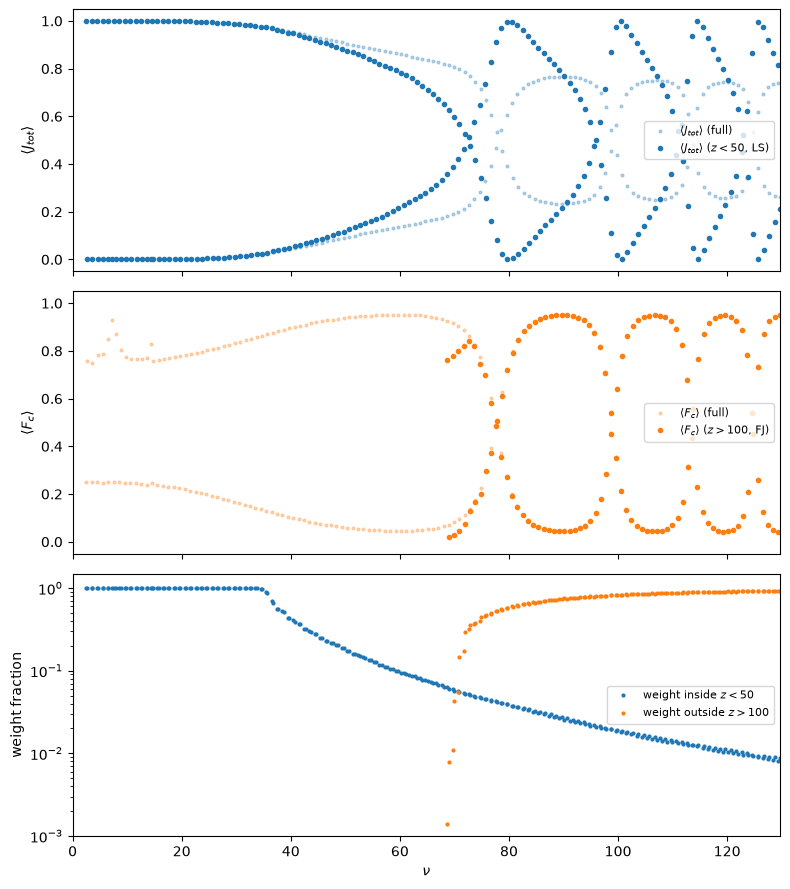

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

# <J_tot>: full vs. inner region
ax = axs[0]
ax.plot(nu, exp_j, "o", color="C0", ms=2, alpha=0.3, label=r"$\langle J_{tot} \rangle$ (full)")
ax.plot(nu, results["exp_j_inner"], "o", color="C0", ms=3, label=rf"$\langle J_{{tot}} \rangle$ ($z < {z_inner}$, LS)")
ax.set_ylabel(r"$\langle J_{tot} \rangle$")

# <F_c>: full vs. outer region
ax = axs[1]
ax.plot(nu, exp_fc, "o", color="C1", ms=2, alpha=0.3, label=r"$\langle F_c \rangle$ (full)")
ax.plot(nu, results["exp_fc_outer"], "o", color="C1", ms=3, label=rf"$\langle F_c \rangle$ ($z > {z_outer}$, FJ)")
ax.set_ylabel(r"$\langle F_c \rangle$")

for ax in axs[:2]:
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="center right", fontsize=8)

# weight fractions of the two regions
ax = axs[2]
ax.plot(nu, results["frac_inner"], "o", color="C0", ms=2, label=rf"weight inside $z < {z_inner}$")
ax.plot(nu, results["frac_outer"], "o", color="C1", ms=2, label=rf"weight outside $z > {z_outer}$")
ax.set_yscale("log")
ax.set_ylim(1e-3, 1.5)
ax.set_ylabel("weight fraction")
ax.set_xlabel(r"$\nu$")
ax.legend(loc="center right", fontsize=8)

axs[0].set_xlim(0, nu[-1])
fig.tight_layout()
plt.show()

**Inner region ($z < 50$, top panel):**

- For $\nu \lesssim 35$ the whole wavefunction lies inside the cut, so the restricted and the full expectation values coincide
  and $J_{\mathrm{tot}}$ is a good quantum number.
- For $35 \lesssim \nu \lesssim 70$ the inner-region value follows the full value and drifts towards $0.5$.
  This mixing is *not* a radial effect, it happens already at short range:
  the splitting between the $^1S_0$ and $^3S_1$ series with the same $n$ is $\Delta E \approx \Delta\delta / \nu^3$
  with a quantum defect difference $\Delta\delta \approx 0.1$ for the 6sns series.
  Around $\nu \approx 40$ it drops below the hyperfine splitting of the ion core ($12.6\,\mathrm{GHz} \approx 1.9 \cdot 10^{-6}$ a.u.),
  so the hyperfine interaction mixes singlet and triplet at all radii.
- For $\nu \gtrsim 70$ the inner-region value oscillates between $0$ and $1$ with the same period as the full value,
  but with opposite phase: the inner region is purely LS coupled exactly for those states, where the full
  $\langle J_{\mathrm{tot}} \rangle$ is maximally mixed (the states studied in `mqdt_radial_wavefunctions_fj_vs_ls.ipynb`).
  These are the states, where the $\nu_i$ of the two FJ channels differ by an integer, so that the two channel wavefunctions
  are in phase at short range and their sum is a pure LS eigenchannel.
  Conversely, where the full value is extremal, the two FJ channels are out of phase at short range and the inner region is mixed.
- Only a small and decreasing fraction of the wavefunction ($\propto \nu^{-3}$) lives in the inner region (bottom panel).

**Outer region ($z > 100$, middle panel):**

- Only states with $\nu \gtrsim 70$ reach out to this region.
- There $\langle F_c \rangle$ is closer to $0$ or $1$ than the full value for most states, since the hyperfine recoupling is complete
  and the two FJ channels separate (the channel with the larger $\nu_i$ extends further out).
- Near the strongly mixed states ($\nu \approx 78$, $99$, $113$, $125$) also the outer region stays mixed,
  because there both FJ channels carry the same weight and their turning points are close to each other.

So the transition from LS to FJ coupling in `mqdt_exp_qn.ipynb` has two ingredients:
a genuine short-range singlet-triplet mixing by the hyperfine interaction setting in around $\nu \approx 40$,
and the radial separation of the two hyperfine channels in the outer region at larger $\nu$,
where an increasing fraction of the probability density is located.